#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### 7. Analysis of Disclosure Timing Patterns by Bad-News Severity


=== Share of After-Hours Disclosures by Bad-News Severity ===
severity_group  total  after_n  mean_decline  after_pct
  -10% to -30%   1306      518          19.5       39.7
  -30% to -50%    901      410          39.8       45.5
    Below -50%   1817      959         233.1       52.8

=== Chi-Square Test: Bad-News Severity × After-Hours Disclosure ===
after_dummy       0    1
severity_group          
-10% to -30%    788  518
-30% to -50%    491  410
Below -50%      858  959

chi2 = 53.390
p-value = 0.0000

=== Logistic Regression Results ===
                           Logit Regression Results                           
Dep. Variable:            after_dummy   No. Observations:                 4024
Model:                          Logit   Df Residuals:                     4021
Method:                           MLE   Df Model:                            2
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                0.009634
Time:                        23:15:33   Log-Likelihood:

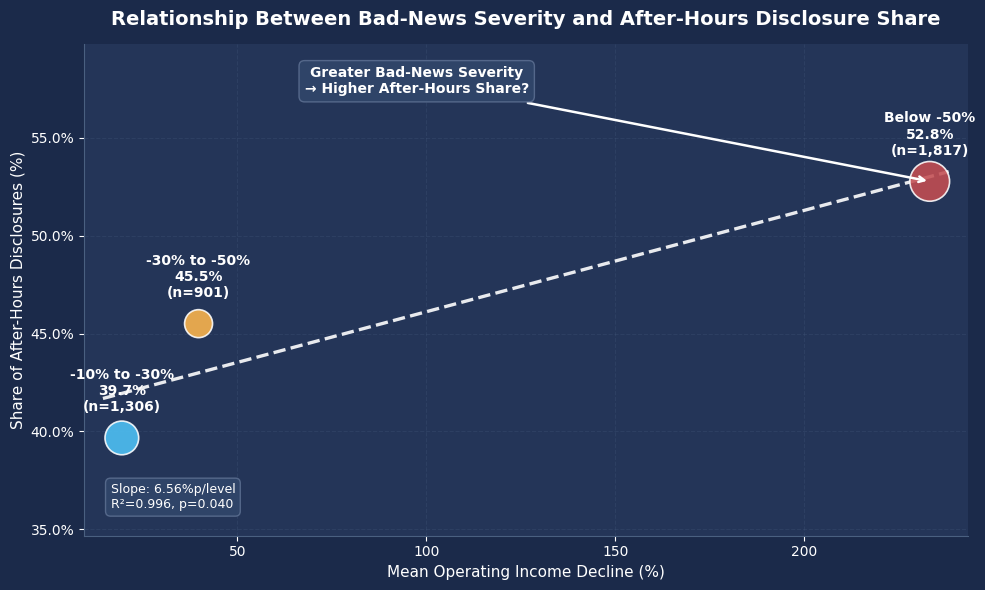

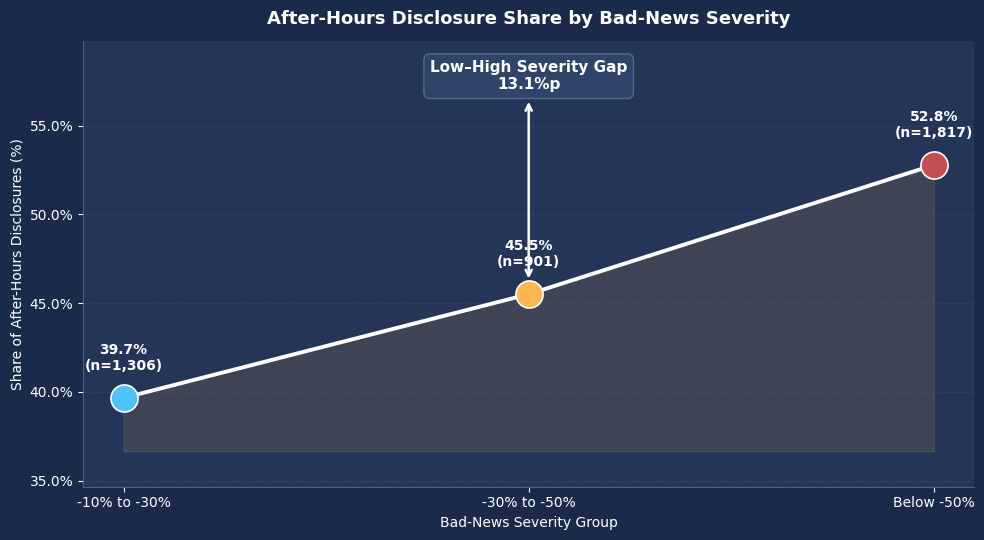


Files saved:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\07_severity_bubble_trend.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\07_severity_gap_focus.png


In [4]:
# ============================================================
# 7. Analysis of Disclosure Timing Patterns by Bad-News Severity
# - Classify observations by operating income decline
# - Test whether more severe bad news is associated with
#   a higher share of after-hours disclosures
# - Improved visualization version
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import statsmodels.formula.api as smf

BG_COLOR = "#1B2A4A"


# ------------------------------------------------------------
# 1. Construct Analysis Dataset
# ------------------------------------------------------------

sev_df = df_hb.copy()

sev_df = sev_df[
    sev_df["news"] == "Bad News"
].copy()

sev_df["after_dummy"] = (
    sev_df["timing"] == "After-hours"
).astype(int)


# ------------------------------------------------------------
# 2. Calculate Bad-News Severity
# ------------------------------------------------------------

sev_df["decline_pct"] = (
    sev_df["oi_chg_pct"].abs() * 100
)


sev_df["severity_group"] = pd.cut(
    sev_df["decline_pct"],
    bins=[10, 30, 50, np.inf],
    labels=[
        "-10% to -30%",
        "-30% to -50%",
        "Below -50%"
    ],
    right=False
)


sev_df = sev_df.dropna(
    subset=["severity_group"]
).copy()


sev_df["severity_group"] = pd.Categorical(
    sev_df["severity_group"],
    categories=[
        "-10% to -30%",
        "-30% to -50%",
        "Below -50%"
    ],
    ordered=True
)


# ------------------------------------------------------------
# 3. Descriptive Statistics
# ------------------------------------------------------------

severity_summary = (
    sev_df
    .groupby(
        "severity_group",
        observed=False
    )
    .agg(
        total=("after_dummy", "size"),
        after_n=("after_dummy", "sum"),
        mean_decline=("decline_pct", "mean")
    )
    .reset_index()
)


severity_summary["after_pct"] = (
    severity_summary["after_n"]
    / severity_summary["total"]
    * 100
)


print(
    "\n=== Share of After-Hours Disclosures "
    "by Bad-News Severity ==="
)


print(
    severity_summary
    .round({
        "mean_decline": 1,
        "after_pct": 1
    })
    .to_string(index=False)
)


# ------------------------------------------------------------
# 4. Chi-Square Test
# ------------------------------------------------------------

contingency = pd.crosstab(
    sev_df["severity_group"],
    sev_df["after_dummy"]
)


chi2, p_chi, dof, expected = stats.chi2_contingency(
    contingency
)


print(
    "\n=== Chi-Square Test: "
    "Bad-News Severity × After-Hours Disclosure ==="
)

print(
    contingency
)


print(
    f"\nchi2 = {chi2:.3f}"
)

print(
    f"p-value = {p_chi:.4f}"
)


# ------------------------------------------------------------
# 5. Logistic Regression
# ------------------------------------------------------------

logit_sev = smf.logit(
    "after_dummy ~ C(severity_group)",
    data=sev_df
).fit(
    disp=False
)


print(
    "\n=== Logistic Regression Results ==="
)

print(
    logit_sev.summary()
)


# ------------------------------------------------------------
# 6. Linear Trend Test
# ------------------------------------------------------------

severity_summary["group_order"] = [
    1,
    2,
    3
]


slope, intercept, r_value, p_value, std_err = stats.linregress(
    severity_summary["group_order"],
    severity_summary["after_pct"]
)


print(
    "\n=== Linear Trend Test by Bad-News Severity ==="
)


print(
    f"Slope: {slope:.3f}%p / severity level"
)

print(
    f"R²: {r_value ** 2:.4f}"
)

print(
    f"p-value: {p_value:.4f}"
)


# ============================================================
# 7. Visualization 1: Bubble Plot + Trend Line
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


x = severity_summary[
    "mean_decline"
]

y = severity_summary[
    "after_pct"
]


bubble_sizes = (
    severity_summary["total"]
    * 0.45
)


colors = [
    "#4FC3F7",
    "#FFB74D",
    "#C44E52"
]


# ------------------------------------------------------------
# Bubble Plot
# ------------------------------------------------------------

ax.scatter(
    x,
    y,
    s=bubble_sizes,
    c=colors,
    alpha=0.88,
    edgecolors="white",
    linewidth=1.2,
    zorder=3
)


# ------------------------------------------------------------
# Trend Line
# ------------------------------------------------------------

coef = np.polyfit(
    x,
    y,
    1
)


trend_fn = np.poly1d(
    coef
)


x_line = np.linspace(
    x.min() - 5,
    x.max() + 5,
    100
)


ax.plot(
    x_line,
    trend_fn(x_line),
    "--",
    color="#FFFFFF",
    linewidth=2.4,
    alpha=0.9,
    zorder=2
)


# ------------------------------------------------------------
# Data Labels
# ------------------------------------------------------------

for _, row in severity_summary.iterrows():

    ax.text(
        row["mean_decline"],
        row["after_pct"] + 1.2,

        f"{row['severity_group']}\n"
        f"{row['after_pct']:.1f}%\n"
        f"(n={int(row['total']):,})",

        ha="center",
        va="bottom",

        fontsize=10,
        fontweight="bold",
        color="white",

        zorder=5
    )


# ------------------------------------------------------------
# Arrow Annotation
# ------------------------------------------------------------

ax.annotate(
    "Greater Bad-News Severity\n"
    "→ Higher After-Hours Share?",

    xy=(
        severity_summary[
            "mean_decline"
        ].iloc[-1],

        severity_summary[
            "after_pct"
        ].iloc[-1]
    ),

    xytext=(
        severity_summary[
            "mean_decline"
        ].mean(),

        severity_summary[
            "after_pct"
        ].max() + 4.5
    ),

    arrowprops=dict(
        arrowstyle="->",
        color="#FFFFFF",
        lw=1.8
    ),

    fontsize=10,
    color="white",
    fontweight="bold",

    ha="center",

    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#32476B",
        edgecolor="#5D7092",
        alpha=0.85
    )
)


# ------------------------------------------------------------
# Trend Statistics Box
# ------------------------------------------------------------

trend_text = (
    f"Slope: {slope:.2f}%p/level\n"
    f"R²={r_value ** 2:.3f}, "
    f"p={p_value:.3f}"
)


ax.text(
    0.03,
    0.05,

    trend_text,

    transform=ax.transAxes,

    ha="left",
    va="bottom",

    fontsize=9,
    color="white",

    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#32476B",
        edgecolor="#5D7092",
        alpha=0.85
    )
)


# ------------------------------------------------------------
# Axis Settings
# ------------------------------------------------------------

ax.set_xlim(
    x.min() - 10,
    x.max() + 10
)


ax.set_ylim(
    y.min() - 5,
    y.max() + 7
)


ax.set_xlabel(
    "Mean Operating Income Decline (%)",
    fontsize=11
)


ax.set_ylabel(
    "Share of After-Hours Disclosures (%)",
    fontsize=11
)


ax.set_title(
    "Relationship Between Bad-News Severity "
    "and After-Hours Disclosure Share",
    fontsize=14,
    fontweight="bold",
    pad=14
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

ax.spines[
    ["top", "right"]
].set_visible(False)


ax.spines[
    ["left", "bottom"]
].set_color(
    "#4A6080"
)


ax.grid(
    linestyle="--",
    alpha=0.25,
    color="#4A6080"
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "07_severity_bubble_trend.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ============================================================
# 8. Visualization 2: Pattern Across Severity Levels
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)


fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


x_pos = np.arange(
    len(severity_summary)
)


# ------------------------------------------------------------
# Line
# ------------------------------------------------------------

ax.plot(
    x_pos,
    severity_summary["after_pct"],
    "o-",
    color="#FFFFFF",
    linewidth=2.8,
    markersize=9,
    zorder=3
)


# ------------------------------------------------------------
# Highlight Area
# ------------------------------------------------------------

ax.fill_between(
    x_pos,
    severity_summary["after_pct"],
    severity_summary["after_pct"].min() - 3,
    color="#FFB74D",
    alpha=0.12,
    zorder=1
)


# ------------------------------------------------------------
# Points and Labels
# ------------------------------------------------------------

for i, row in severity_summary.iterrows():

    ax.scatter(
        i,
        row["after_pct"],

        s=380,

        color=colors[i],

        edgecolor="white",
        linewidth=1.2,

        zorder=4
    )


    ax.text(
        i,
        row["after_pct"] + 1.4,

        f"{row['after_pct']:.1f}%\n"
        f"(n={int(row['total']):,})",

        ha="center",
        va="bottom",

        fontsize=10,
        fontweight="bold",
        color="white",

        zorder=5
    )


# ------------------------------------------------------------
# Highlight Difference Between Low and High Severity
# ------------------------------------------------------------

low_pct = (
    severity_summary[
        "after_pct"
    ].iloc[0]
)


high_pct = (
    severity_summary[
        "after_pct"
    ].iloc[-1]
)


gap = (
    high_pct
    - low_pct
)


ax.annotate(
    f"Low–High Severity Gap\n"
    f"{gap:.1f}%p",

    xy=(
        1.0,
        (
            low_pct
            + high_pct
        ) / 2
    ),

    xytext=(
        1.0,
        severity_summary[
            "after_pct"
        ].max() + 5
    ),

    ha="center",
    va="center",

    fontsize=11,
    color="white",
    fontweight="bold",

    arrowprops=dict(
        arrowstyle="<->",
        color="#FFFFFF",
        lw=1.8
    ),

    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#32476B",
        edgecolor="#5D7092",
        alpha=0.85
    )
)


# ------------------------------------------------------------
# Axis Settings
# ------------------------------------------------------------

ax.set_xticks(
    x_pos
)


ax.set_xticklabels(
    severity_summary[
        "severity_group"
    ]
)


ax.set_ylim(
    severity_summary[
        "after_pct"
    ].min() - 5,

    severity_summary[
        "after_pct"
    ].max() + 7
)


ax.set_xlabel(
    "Bad-News Severity Group",
    fontsize=10
)


ax.set_ylabel(
    "Share of After-Hours Disclosures (%)",
    fontsize=10
)


ax.set_title(
    "After-Hours Disclosure Share "
    "by Bad-News Severity",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

ax.spines[
    ["top", "right"]
].set_visible(False)


ax.spines[
    ["left", "bottom"]
].set_color(
    "#4A6080"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "07_severity_gap_focus.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ============================================================
# 9. Saved Files
# ============================================================

print(
    "\nFiles saved:"
)


print(
    OUTPUT_DIR
    / "07_severity_bubble_trend.png"
)


print(
    OUTPUT_DIR
    / "07_severity_gap_focus.png"
)

# 7. Analysis of Disclosure Timing Patterns by Bad-News Severity

## 7.1 Analysis Objective

This section examines whether firms' disclosure-timing choices vary according to the severity of bad news.

In particular, bad-news severity was classified based on the percentage decline in operating income as follows.

| Severity Group | Criterion |
|---|---:|
| Mild Bad News | -10% to -30% |
| Moderate Bad News | -30% to -50% |
| Severe Bad News | Below -50% |

This classification allows for a direct test of whether firms become more likely to choose after-hours disclosure as the information being disclosed becomes more negative.

---

## 7.2 Share of After-Hours Disclosures by Bad-News Severity

The results show a clear increase in the share of after-hours disclosures as bad-news severity increases.

| Bad-News Severity | After-Hours Disclosure Share |
|---|---:|
| -10% to -30% | 39.7% |
| -30% to -50% | 45.5% |
| Below -50% | 52.8% |

In particular, when operating income declined by more than 50%, more than half of the disclosures were released after market hours.

This suggests that firms may make greater use of after-hours disclosure strategies as the information being disclosed becomes more negative.

---

## 7.3 Chi-Square Test Results

A chi-square test examining the relationship between bad-news severity and after-hours disclosure revealed a highly statistically significant difference.

```text
chi2 = 53.390
p < 0.001
```

This indicates that bad-news severity and disclosure-timing choice are not independent, with the probability of after-hours disclosure tending to increase as the severity of bad news increases.

---

## 7.4 Logistic Regression Results

The logistic regression results also show that the likelihood of choosing after-hours disclosure increases with bad-news severity.

Relative to the reference group (-10% to -30%):

```text
-30% to -50% : coef = 0.239, p = 0.006
Below -50%   : coef = 0.531, p < 0.001
```

In particular, the most severe bad-news group (below -50%) has the largest coefficient and is highly statistically significant.

This suggests that firms may have stronger incentives to choose after-hours disclosure when releasing more severe negative information.

---

## 7.5 Linear Trend Test

A linear trend test was conducted to examine changes in the share of after-hours disclosures across increasing levels of bad-news severity.

```text
Slope = +6.56%p / severity level
R² = 0.996
p = 0.040
```

The results indicate that the share of after-hours disclosures increases by approximately 6.6 percentage points, on average, for each one-level increase in bad-news severity.

The very high R² also indicates a strong monotonic increasing relationship between bad-news severity and the share of after-hours disclosures.

---

## 7.6 Overall Interpretation

Overall, firms appear to adjust their disclosure timing not only according to whether the information is bad news, but also according to the severity of that bad news.

In particular, the share of after-hours disclosures systematically increases as the decline in operating income becomes larger, with more than half of the most severe bad-news disclosures being released after market hours.

This suggests that firms may have strategic incentives to disclose relatively more negative information after market hours in an attempt to manage investor reactions or mitigate the immediate information shock.

Therefore, these results indicate that disclosure-timing choices are not merely random but are closely associated with the severity of negative information.